In [ ]:
# Validation notebook: single best model. K from mean_NORM_con_22.csv, t_step=0.01, t_max=40.
# Transform held-out validation data and plot beta + spaghetti (no candidate comparison).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from COMIND_transformer.utils import solve_system
from COMIND_transformer.subtyping_em_transformer import SubtypingEM
from sklearn.model_selection import train_test_split

# Paths and settings
# K_PATH = "/home/dsemchin/data/iit_connectivity_matrix/streamline_normalized_top_regions/iit_connectome_top_20.csv"
# PPMI_CSV = "/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv"
# NPZ_PATH = "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/2026_2_22_ppmi_new_bic_iitconnect_2/results/PPMI_subtyping_grid_betajsd_206_lambda_f1p200_lambda_cog0p000_lambda_scalar10p000_lambda_jsd10_lambda_beta0p000_n_subtypes3.npz"

K_PATH = # connectivity matrix here
PPMI_CSV = # data csv here
NPZ_PATH = # COMIND fitted model here

t_max = 40
t_step = 0.01
n_biomarkers = 68

biomarker_names = ['L_bankssts_thickavg', 'L_caudalanteriorcingulate_thickavg', 'L_caudalmiddlefrontal_thickavg', 'L_cuneus_thickavg',
                   'L_entorhinal_thickavg', 'L_fusiform_thickavg', 'L_inferiorparietal_thickavg', 'L_inferiortemporal_thickavg',
                   'L_isthmuscingulate_thickavg', 'L_lateraloccipital_thickavg', 'L_lateralorbitofrontal_thickavg',
                   'L_lingual_thickavg', 'L_medialorbitofrontal_thickavg', 'L_middletemporal_thickavg', 'L_parahippocampal_thickavg',
                   'L_paracentral_thickavg', 'L_parsopercularis_thickavg', 'L_parsorbitalis_thickavg', 'L_parstriangularis_thickavg',
                   'L_pericalcarine_thickavg', 'L_postcentral_thickavg', 'L_posteriorcingulate_thickavg', 'L_precentral_thickavg',
                   'L_precuneus_thickavg', 'L_rostralanteriorcingulate_thickavg', 'L_rostralmiddlefrontal_thickavg', 'L_superiorfrontal_thickavg',
                   'L_superiorparietal_thickavg', 'L_superiortemporal_thickavg', 'L_supramarginal_thickavg', 'L_frontalpole_thickavg',
                   'L_temporalpole_thickavg', 'L_transversetemporal_thickavg', 'L_insula_thickavg', 'R_bankssts_thickavg', 'R_caudalanteriorcingulate_thickavg',
                   'R_caudalmiddlefrontal_thickavg', 'R_cuneus_thickavg', 'R_entorhinal_thickavg', 'R_fusiform_thickavg', 'R_inferiorparietal_thickavg',
                   'R_inferiortemporal_thickavg', 'R_isthmuscingulate_thickavg', 'R_lateraloccipital_thickavg', 'R_lateralorbitofrontal_thickavg',
                   'R_lingual_thickavg', 'R_medialorbitofrontal_thickavg', 'R_middletemporal_thickavg', 'R_parahippocampal_thickavg', 'R_paracentral_thickavg',
                   'R_parsopercularis_thickavg', 'R_parsorbitalis_thickavg', 'R_parstriangularis_thickavg', 'R_pericalcarine_thickavg', 'R_postcentral_thickavg',
                   'R_posteriorcingulate_thickavg', 'R_precentral_thickavg', 'R_precuneus_thickavg', 'R_rostralanteriorcingulate_thickavg',
                   'R_rostralmiddlefrontal_thickavg', 'R_superiorfrontal_thickavg', 'R_superiorparietal_thickavg', 'R_superiortemporal_thickavg',
                   'R_supramarginal_thickavg', 'R_frontalpole_thickavg', 'R_temporalpole_thickavg', 'R_transversetemporal_thickavg', 'R_insula_thickavg']

ROI = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]
ROI_names = [biomarker_names[i] for i in ROI]

In [2]:
# Load connectivity matrix K
df_K = pd.read_csv(K_PATH)
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum
print("K shape:", K.shape)

K shape: (68, 68)


Loaded npz keys: ['theta_history', 'cog_history', 'beta_history', 'lse_history', 'assignment_history', 'beta_val', 'beta_val_with_cog', 'beta_val_no_cog', 'val_assignments_with_cog', 'val_assignments_no_cog', 'val_lse_with_cog', 'val_lse_no_cog', 'candidate', 'f_init', 'train_assignments', 'val_assignments', 'train_ids', 'val_ids', 'final_assignments', 'cluster_f', 'cluster_cog_a', 'cluster_cog_b', 'final_scalar_K', 'final_s', 'n_subtypes', 'n_subtypes_list', 'lambda_f', 'lambda_cog', 'lambda_scalar', 'lambda_jsd', 'lambda_beta', 'param_grid_size', 'n_hyper_per_K', 'k_idx', 'sub_cand', 'bic', 'bic_neg2_log_L', 'bic_penalty', 'n_obs', 'bic_n_params', 'lse_final', 'cv_mean_lse', 'cv_std_lse', 'cv_variance', 'cv_per_fold_lse', 'n_folds', 'sse_per_biomarker', 'n_obs_rows']
Final train LSE (from npz): 429.44961166744775
Top ROI indices by L2 subtype separation: [4, 38, 14, 48, 58, 30, 65, 64, 1, 35]
Top ROI names: ['L_entorhinal_thickavg', 'R_entorhinal_thickavg', 'L_parahippocampal_thickav

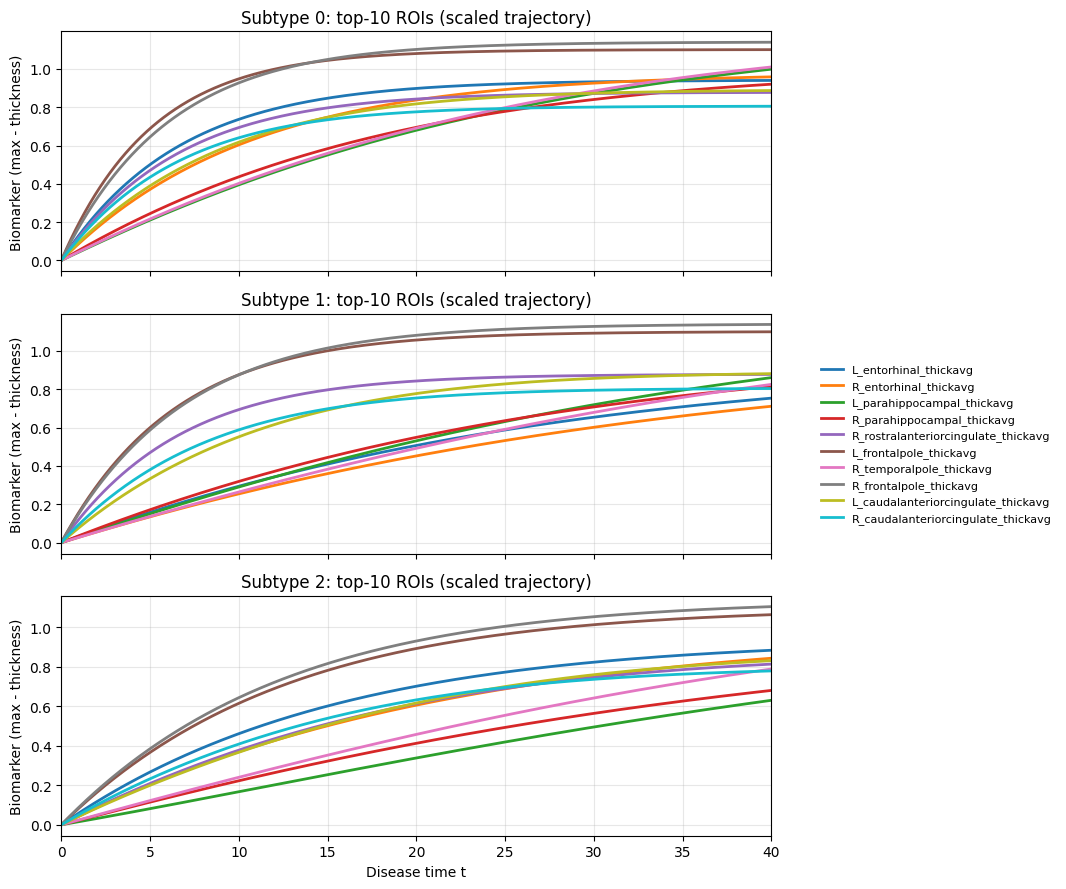

In [3]:
# Load best model from npz and build SubtypingEM for transform (no fit)
from matplotlib.lines import Line2D
data = np.load(NPZ_PATH, allow_pickle=True)
print("Loaded npz keys:", list(data.files))

cluster_f = np.asarray(data["cluster_f"])               # (n_subtypes, n_biomarkers)
cluster_cog_a = np.asarray(data["cluster_cog_a"])       # (n_subtypes, n_cog_features)
cluster_cog_b = np.atleast_1d(np.asarray(data["cluster_cog_b"]))  # (n_subtypes,)
final_s = np.asarray(data["final_s"])                   # (n_biomarkers,)
final_scalar_K = float(np.asarray(data["final_scalar_K"]).item())

# Prefer stored n_subtypes if present; otherwise infer from arrays
n_subtypes = int(data["n_subtypes"]) if "n_subtypes" in data.files else cluster_f.shape[0]

# Build model object with loaded parameters
em = SubtypingEM(
    K=K,
    t_max=t_max,
    step=t_step,
    n_subtypes=n_subtypes,
    lambda_cog=0.0,   # transform override can still use_cognitive_prior=True/False
    jac_toggle=True,
    verbose=0
)

em.cluster_f = [np.ravel(cluster_f[k]) for k in range(n_subtypes)]
em.cluster_cog_a = [np.ravel(cluster_cog_a[k]) for k in range(n_subtypes)]
em.cluster_cog_b = [float(cluster_cog_b[k]) for k in range(n_subtypes)]
em.final_s = final_s
em.final_scalar_K = final_scalar_K
em.t_span = np.linspace(0, em.t_max, int(em.t_max / em.step))

# Optional compatibility attrs used in some helper methods
em.theta = np.concatenate([np.ravel(em.cluster_f[0]), em.final_s, [em.final_scalar_K]])
em.X_pred = solve_system(np.zeros(n_biomarkers), em.cluster_f[0], K, em.t_span, em.final_scalar_K)

print("Final train LSE (from npz):", data["lse_history"][-1])

# Precompute subtype trajectories + top-10 ROI indices by L2 distance metric
# Uses scaled trajectories for ROI ranking; same idea as analyze_results

x0 = np.zeros(n_biomarkers)
Xtraj_by_subtype = [solve_system(x0, cluster_f[k], K, em.t_span, final_scalar_K) for k in range(n_subtypes)]
Xtraj_by_subtype = np.asarray(Xtraj_by_subtype)  # (n_subtypes, n_biomarkers, n_time)

# Scaled trajectories for ranking
trajs_scaled = final_s[None, :, None] * Xtraj_by_subtype  # (n_subtypes, n_biomarkers, n_time)

dt_span = np.diff(em.t_span)
if len(dt_span) == 0:
    dt_span = np.array([1.0])
else:
    dt_span = np.concatenate([dt_span, [dt_span[-1]]])

curve_l2_max = np.zeros(n_biomarkers)
for b in range(n_biomarkers):
    for i in range(n_subtypes):
        for j in range(i + 1, n_subtypes):
            diff = trajs_scaled[i, b, :] - trajs_scaled[j, b, :]
            l2 = np.sqrt(np.sum(diff**2 * dt_span))
            curve_l2_max[b] = max(curve_l2_max[b], l2)

TOP_N = 10
top_indices = np.argsort(curve_l2_max)[-TOP_N:][::-1]
top_ROI_names = [biomarker_names[idx] for idx in top_indices]

print("Top ROI indices by L2 subtype separation:", top_indices.tolist())
print("Top ROI names:", top_ROI_names)

n_show = n_subtypes
fig, axes = plt.subplots(n_show, 1, figsize=(8, 3 * max(n_show, 1)), sharex=True)
if n_show == 1:
    axes = [axes]
roi_line_colors = plt.cm.tab10(np.linspace(0, 1, min(10, len(top_indices))))
for k in range(n_show):
    ax = axes[k]
    X_pred_k = solve_system(np.zeros(n_biomarkers), em.cluster_f[k], K, em.t_span, em.final_scalar_K)
    for r_idx, (roi, c) in enumerate(zip(top_indices, roi_line_colors)):
        traj = em.final_s[roi] * X_pred_k[roi]
        ax.plot(em.t_span, traj, color=c, lw=2, label=top_ROI_names[r_idx])
    ax.set_ylabel("Biomarker (max - thickness)")
    ax.set_title(f"Subtype {k}: top-{len(top_indices)} ROIs (scaled trajectory)")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)
axes[-1].set_xlabel("Disease time t")
legend_handles = [
    Line2D([0], [0], color=roi_line_colors[i], lw=2, label=top_ROI_names[i])
    for i in range(len(top_indices))
]
fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    frameon=False,
)
plt.tight_layout()
plt.show()


Subtype 0:
s_ij = 42.2486 + -0.7929 * MCATOT + -0.2359 * TD_score + 0.9818 * PIGD_score

Subtype 1:
s_ij = 37.2019 + -0.5173 * MCATOT + 0.0614 * TD_score + -0.2092 * PIGD_score

Subtype 2:
s_ij = -10.2949 + 1.3685 * MCATOT + -0.0191 * TD_score + 0.7661 * PIGD_score


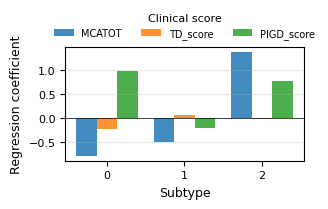

In [4]:
# cognitive equations per subtype (print only)
cluster_cog_a = np.asarray(data["cluster_cog_a"])
cluster_cog_b = np.atleast_1d(np.asarray(data["cluster_cog_b"]))
n_subtypes = cluster_cog_b.shape[0]

cog_feature_names = ["MCATOT", "TD_score", "PIGD_score"]

for subtype in range(n_subtypes):
    print(f"\nSubtype {subtype}:")
    # print(f"  Intercept (cog_b): {cluster_cog_b[subtype]:.4f}")
    # for i, name in enumerate(cog_feature_names):
    #     print(f"  {name} coefficient: {cluster_cog_a[subtype, i]:.4f}")
    print(
        f"s_ij = {cluster_cog_b[subtype]:.4f} "
        f"+ {cluster_cog_a[subtype, 0]:.4f} * MCATOT "
        f"+ {cluster_cog_a[subtype, 1]:.4f} * TD_score "
        f"+ {cluster_cog_a[subtype, 2]:.4f} * PIGD_score"
    )

fig, ax = plt.subplots(figsize=(3.3, 2.5))  # single-column friendly

x = np.arange(n_subtypes)
width = 0.8 / len(cog_feature_names)

for feat_idx, feat_name in enumerate(cog_feature_names):
    offset = (feat_idx - (len(cog_feature_names) - 1) / 2) * width
    values = cluster_cog_a[:, feat_idx]
    ax.bar(
        x + offset,
        values,
        width,
        label=feat_name,
        alpha=0.85,
    )

ax.set_xlabel("Subtype", fontsize=9)
ax.set_ylabel("Regression coefficient", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f"{s}" for s in range(n_subtypes)], fontsize=8)
ax.tick_params(axis="y", labelsize=8)

# Light horizontal grid for readability
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)

# Compact legend above/below panel (not inside), small font
ax.legend(
    title="Clinical score",
    fontsize=7,
    title_fontsize=8,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.38),
    ncol=len(cog_feature_names),
)

# No title: caption will carry the description
plt.tight_layout()
#plt.savefig("cog_regression_coeffs_by_subtype.pdf", bbox_inches="tight", dpi=300)
plt.show()

### Data loading

In [5]:
# Load PPMI data, build patient list.
# For another PD dataset: same preprocessing, then set USE_TRAIN_VAL_SPLIT = False
# so that X_val = X_all (no split) and transform/plots use all subjects.

USE_TRAIN_VAL_SPLIT = False   # False = use all data as "validation" (no held-out split)
CLINICAL_SCORE_FILTER = False # True = require all 3 clinical scores per visit; False = do not filter on clinical availability
REQUIRE_LONGITUDINAL = True  # True: keep only subjects with >1 visit, False: keep 1+ visit subjects

clinical_cols = ["MCATOT", "TD_score", "PIGD_score"]

df = pd.read_csv(PPMI_CSV)

# Biomarkers used by model (always required)
biomarker_cols = [
    c for c in df.columns
    if c.startswith(("L_", "R_")) and c.endswith("_thickavg") and not c.endswith("_thickavg_resid")
]

print("raw shape:", df.shape)
df = df.replace([np.inf, -np.inf], np.nan) # Treat inf as missing
df = df.dropna(subset=biomarker_cols) # Always require biomarker availability

# Optional clinical filtering
if CLINICAL_SCORE_FILTER:
    df = df.dropna(subset=clinical_cols)
    print("Clinical filter ON: requiring MCATOT + TD_score + PIGD_score (all present)") # Keep only visits with complete clinical triad
else:
    print("Clinical filter OFF: allowing missing clinical scores (no imputation)") # Keep all visits regardless of missing clinical columns

print("post-filter shape:", df.shape)

# QC for users: how complete are clinical fields among retained visits?
clinical_nonmissing_count = df[clinical_cols].notna().sum(axis=1).value_counts().sort_index()
print("\nVisits by # available clinical scores (0..3):")
print(clinical_nonmissing_count)

print(df[["subj_id", "time", "NHY"]].head(4))

subj_counts = df["subj_id"].value_counts()
print(f"total subjects (pre-visit-filter): {len(subj_counts)}")

if REQUIRE_LONGITUDINAL:
    keep_ids = subj_counts[subj_counts > 1].index
    print(f"Keeping longitudinal only (>1 visit): {len(keep_ids)} subjects")
else:
    keep_ids = subj_counts.index
    n_single_visit = int((subj_counts == 1).sum())
    print(f"Keeping all subjects (including {n_single_visit} single-visit subjects): {len(keep_ids)} subjects")

df = df[df["subj_id"].isin(keep_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])
print("after subject-visit filter + dedup:", df.shape)

# Build arrays
X_obs = df[biomarker_cols].to_numpy()
X_obs = np.max(X_obs, axis=0) - X_obs

dt_all = (df["time"].to_numpy() / 12.0)
ids_all = df["subj_id"].to_numpy()
nhy_all = df["NHY"].to_numpy()
cog_all = df[clinical_cols].to_numpy()  # keeps NaN when CLINICAL_SCORE_FILTER=False

def create_patient_list(X_obs, ids, dt, cog, nhy):
    unique_ids = np.unique(ids)
    patient_list = []
    for pid in unique_ids:
        mask = (ids == pid)
        patient_list.append({
            "id": pid,
            "X_obs": X_obs[mask],
            "dt": dt[mask],
            "cog": cog[mask],
            "nhy": nhy[mask],
        })
    return patient_list

X_all = create_patient_list(X_obs, ids_all, dt_all, cog_all, nhy_all)

if USE_TRAIN_VAL_SPLIT:
    X_train, X_val = train_test_split(X_all, test_size=0.2, random_state=75)
    print("n_train:", len(X_train), "n_val:", len(X_val))
else:
    X_train, X_val = [], X_all
    print("No split: using all", len(X_val), "subjects as validation set.")

raw shape: (880, 250)
Clinical filter OFF: allowing missing clinical scores (no imputation)
post-filter shape: (874, 250)

Visits by # available clinical scores (0..3):
0      1
1      1
2      4
3    868
Name: count, dtype: int64
   subj_id  time  NHY
0     4107     0  2.0
2     3275     0  2.0
3     3279     0  2.0
4     3076     0  2.0
total subjects (pre-visit-filter): 374
Keeping longitudinal only (>1 visit): 148 subjects
after subject-visit filter + dedup: (510, 250)
No split: using all 148 subjects as validation set.


## Data **Transform**
#### Transform options
- **`use_cognitive_prior`**  
  Controls whether clinical/cognitive features (`cog`) are used in beta/subtype inference during `transform`.
  - `True`: includes the cognitive prior term (weighted by model `lambda_cog`).
  - `False`: ignores cognitive prior (`lambda_cog` effectively set to 0 for transform), so inference is based on biomarker trajectories + time only.

- **`method`**  
  Controls how subtype and beta are chosen.
  - `"legacy"`: screen subtype at fixed initial beta (10, clipped by `t_max`), then optimize beta once for the selected subtype.
  - `"multiple_inits"`: for each subtype, optimize beta from multiple starts (`{10,20,30}`), keep each subtype’s best fit, then choose subtype with lowest optimized loss (more robust, slower).

In [6]:
# Transform validation set: estimate betas + subtype assignments, then compute validation LSE
tr = em.transform(X_val, use_cognitive_prior=False, method="legacy")
#tr = em.transform(X_val, use_cognitive_prior=False, method="multiple_inits")

beta_val = tr["beta"]
subtype_val = tr["subtype"]

val_lse = em._compute_val_score(X_val, beta_val)

print("Validation LSE:", val_lse)
print("Validation betas: min=%.4f, max=%.4f, mean=%.4f" % (beta_val.min(), beta_val.max(), beta_val.mean()))

# Compact subtype summary
unique_subtypes, counts = np.unique(subtype_val, return_counts=True)
print("Validation subtype counts:", dict(zip(unique_subtypes.tolist(), counts.tolist())))

Estimating beta and subtype assignments: 100%|██████████| 148/148 [00:05<00:00, 29.06it/s]

Validation LSE: 680.3764719046078
Validation betas: min=9.5645, max=39.0132, mean=19.3525
Validation subtype counts: {0: 136, 1: 8, 2: 4}


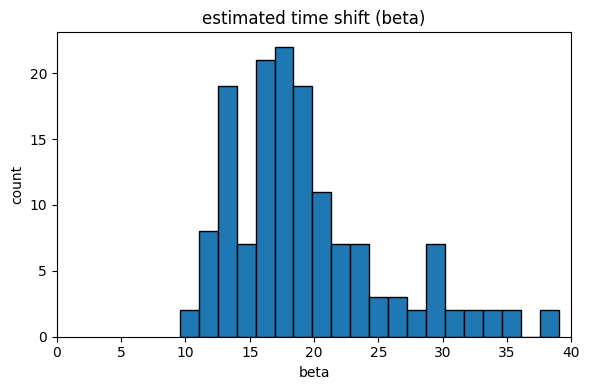


Subtype 0 Beta:
  n: 136
  Mean: 19.6927  Median: 18.2293  Std: 6.0622

Subtype 1 Beta:
  n: 8
  Mean: 15.2819  Median: 14.5393  Std: 2.3325

Subtype 2 Beta:
  n: 4
  Mean: 15.9258  Median: 15.9013  Std: 2.4890


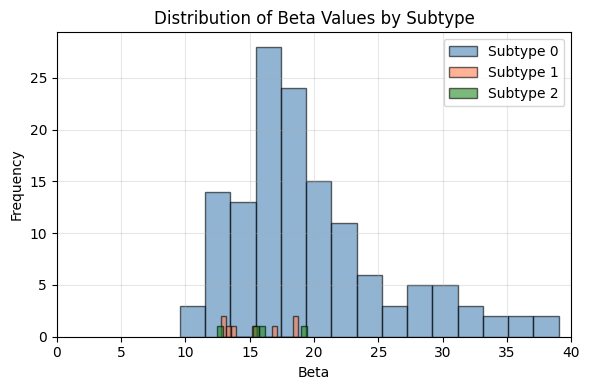

In [7]:
# Beta distribution (validation set)
plt.figure(figsize=(6, 4))
plt.hist(beta_val, bins=20, edgecolor="k")
plt.xlabel("beta")
plt.ylabel("count")
plt.title("estimated time shift (beta)")
plt.xlim(0,40)
plt.tight_layout()
plt.show()

# Beta distributions by discovered subtype (validation set)
plt.figure(figsize=(6, 4))
colors = ["steelblue", "coral", "forestgreen", "purple", "goldenrod", "teal"]

n_subtypes = int(np.max(subtype_val)) + 1
for subtype in range(n_subtypes):
    beta_subtype = beta_val[subtype_val == subtype]
    if len(beta_subtype) == 0:
        print(f"\nSubtype {subtype}: no subjects in validation.")
        continue

    plt.hist(
        beta_subtype,
        bins=15,
        alpha=0.6,
        label=f"Subtype {subtype}",
        color=colors[subtype % len(colors)],
        edgecolor="black",
    )

    print(f"\nSubtype {subtype} Beta:")
    print(f"  n: {len(beta_subtype)}")
    print(f"  Mean: {np.mean(beta_subtype):.4f}  Median: {np.median(beta_subtype):.4f}  Std: {np.std(beta_subtype):.4f}")

plt.xlabel("Beta")
plt.ylabel("Frequency")
plt.title("Distribution of Beta Values by Subtype")
plt.xlim(0, 40)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Counts: TD/PIGD (final visit) vs Discovered subtype

Subtype                  0  1  2  Total
TD/PIGD (final visit)                  
Indeterminate           15  0  0     15
PIGD                    65  4  2     71
TD                      56  4  2     62
Total                  136  8  4    148


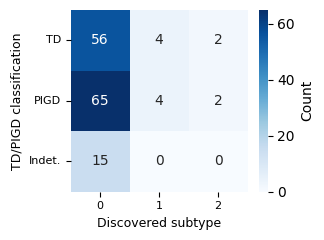

In [8]:
# TD/PIGD classification vs discovered subtype (validation subjects only)

# Map validation patient IDs to subtype assignments
pid_to_assignment = {X_val[i]["id"]: int(subtype_val[i]) for i in range(len(X_val))}

# Build TD/PIGD classification on df
df_cls = df.copy()
df_cls["TD_mean"] = df_cls["TD_score"] / 10.0
df_cls["PIGD_mean"] = df_cls["PIGD_score"] / 3.0
df_cls["TD_PIGD_ratio"] = np.where(
    df_cls["PIGD_mean"] == 0,
    np.inf,
    df_cls["TD_mean"] / df_cls["PIGD_mean"],
)

conditions = [
    (df_cls["TD_PIGD_ratio"] >= 1.5),
    (df_cls["TD_mean"] > 0) & (df_cls["PIGD_mean"] == 0),
    (df_cls["TD_PIGD_ratio"] <= 1.0),
    (df_cls["TD_mean"] == 0) & (df_cls["PIGD_mean"] > 0),
]
values = ["TD", "TD", "PIGD", "PIGD"]
df_cls["TD_PIGD_Classification"] = np.select(conditions, values, default="Indeterminate")

# Use final visit per patient (matches your analyze cell behavior with idxmax)
visit_df = df_cls.loc[df_cls.groupby("subj_id")["time"].idxmax(), ["subj_id", "time", "TD_PIGD_Classification"]].copy()
visit_df["discovered_subtype"] = visit_df["subj_id"].map(pid_to_assignment)

# Keep only patients present in validation split (i.e., assigned)
visit_df = visit_df[visit_df["discovered_subtype"].notna()].copy()
visit_df["discovered_subtype"] = visit_df["discovered_subtype"].astype(int)

# Printed confusion table (with totals)
confusion = pd.crosstab(
    visit_df["TD_PIGD_Classification"],
    visit_df["discovered_subtype"],
    margins=True,
    margins_name="Total",
)
confusion.index.name = "TD/PIGD (final visit)"
confusion.columns.name = "Subtype"

print("Counts: TD/PIGD (final visit) vs Discovered subtype\n")
print(confusion)

# Heatmap (without margins)
plot_mat = pd.crosstab(
    visit_df["TD_PIGD_Classification"],
    visit_df["discovered_subtype"],
)

for label in ["TD", "PIGD", "Indeterminate"]:
    if label not in plot_mat.index:
        plot_mat.loc[label] = 0

plot_mat = plot_mat.reindex([c for c in ["TD", "PIGD", "Indeterminate"] if c in plot_mat.index])
plot_mat = plot_mat.sort_index(axis=1)

fig, ax = plt.subplots(figsize=(3.3, 2.5))
sns.heatmap(
    plot_mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    cbar_kws={"label": "Count"},
)

ax.set_yticklabels(["TD", "PIGD", "Indet."], fontsize=8)
ax.set_xlabel("Discovered subtype", fontsize=9)
ax.set_ylabel("TD/PIGD classification", fontsize=9)
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1314/304400581.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_val, x="NHY", y="t_ij", palette="plasma", inner="box")


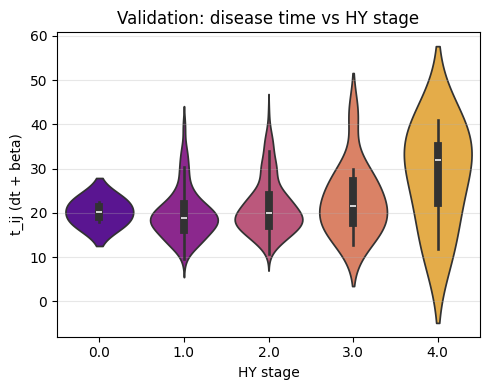

/tmp/ipykernel_1314/304400581.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


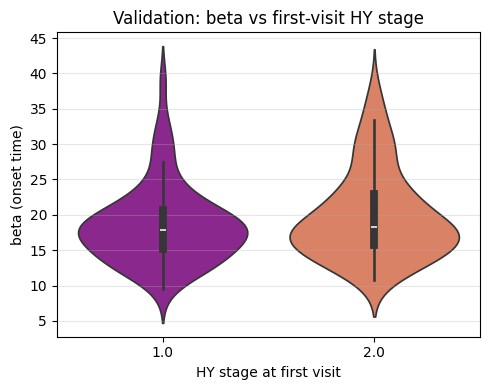

/tmp/ipykernel_1314/304400581.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


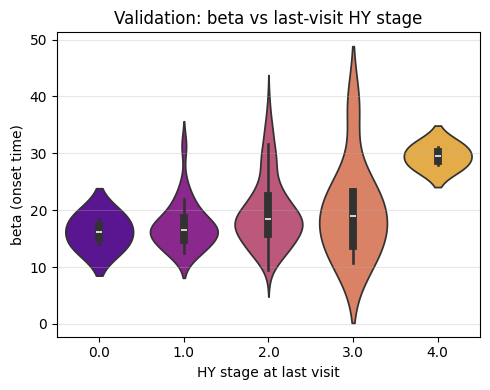

In [9]:
# t_ij = dt + beta per visit for validation; violin NHY vs t_ij
t_ij_val = np.concatenate([p["dt"] + beta_val[i] for i, p in enumerate(X_val)])
nhy_val = np.concatenate([p["nhy"] for p in X_val])
df_val = pd.DataFrame({"t_ij": t_ij_val, "NHY": nhy_val}).dropna()
plt.figure(figsize=(5, 4))
sns.violinplot(data=df_val, x="NHY", y="t_ij", palette="plasma", inner="box")
plt.xlabel("HY stage")
plt.ylabel("t_ij (dt + beta)")
plt.title("Validation: disease time vs HY stage")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Beta (subject-level) vs first-visit NHY (subject-level)

# Define first visit as smallest dt (earliest observed visit)
beta_subject = []
nhy_first_visit = []
nhy_final_visit = []
for i, p in enumerate(X_val):
    dt_i = np.asarray(p["dt"])
    nhy_i = np.asarray(p["nhy"])

    if len(dt_i) == 0 or len(nhy_i) == 0:
        continue

    first_idx = np.argmin(dt_i)   # earliest visit
    last_idx = np.argmax(dt_i)   # latest visit
    beta_subject.append(float(beta_val[i]))
    nhy_first_visit.append(float(nhy_i[first_idx]))
    nhy_final_visit.append(float(nhy_i[last_idx]))

df_beta_first = pd.DataFrame({
    "beta": beta_subject,
    "NHY_first": nhy_first_visit
}).dropna()

df_beta_final = pd.DataFrame({
    "beta": beta_subject,
    "NHY_final": nhy_final_visit
}).dropna()

plt.figure(figsize=(5, 4))
sns.violinplot(
    data=df_beta_first,
    x="NHY_first",
    y="beta",
    palette="plasma",
    inner="box"
)
plt.xlabel("HY stage at first visit")
plt.ylabel("beta (onset time)")
plt.title("Validation: beta vs first-visit HY stage")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.violinplot(
    data=df_beta_final,
    x="NHY_final",
    y="beta",
    palette="plasma",
    inner="box"
)
plt.xlabel("HY stage at last visit")
plt.ylabel("beta (onset time)")
plt.title("Validation: beta vs last-visit HY stage")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Subtype 0: 136 validation patients


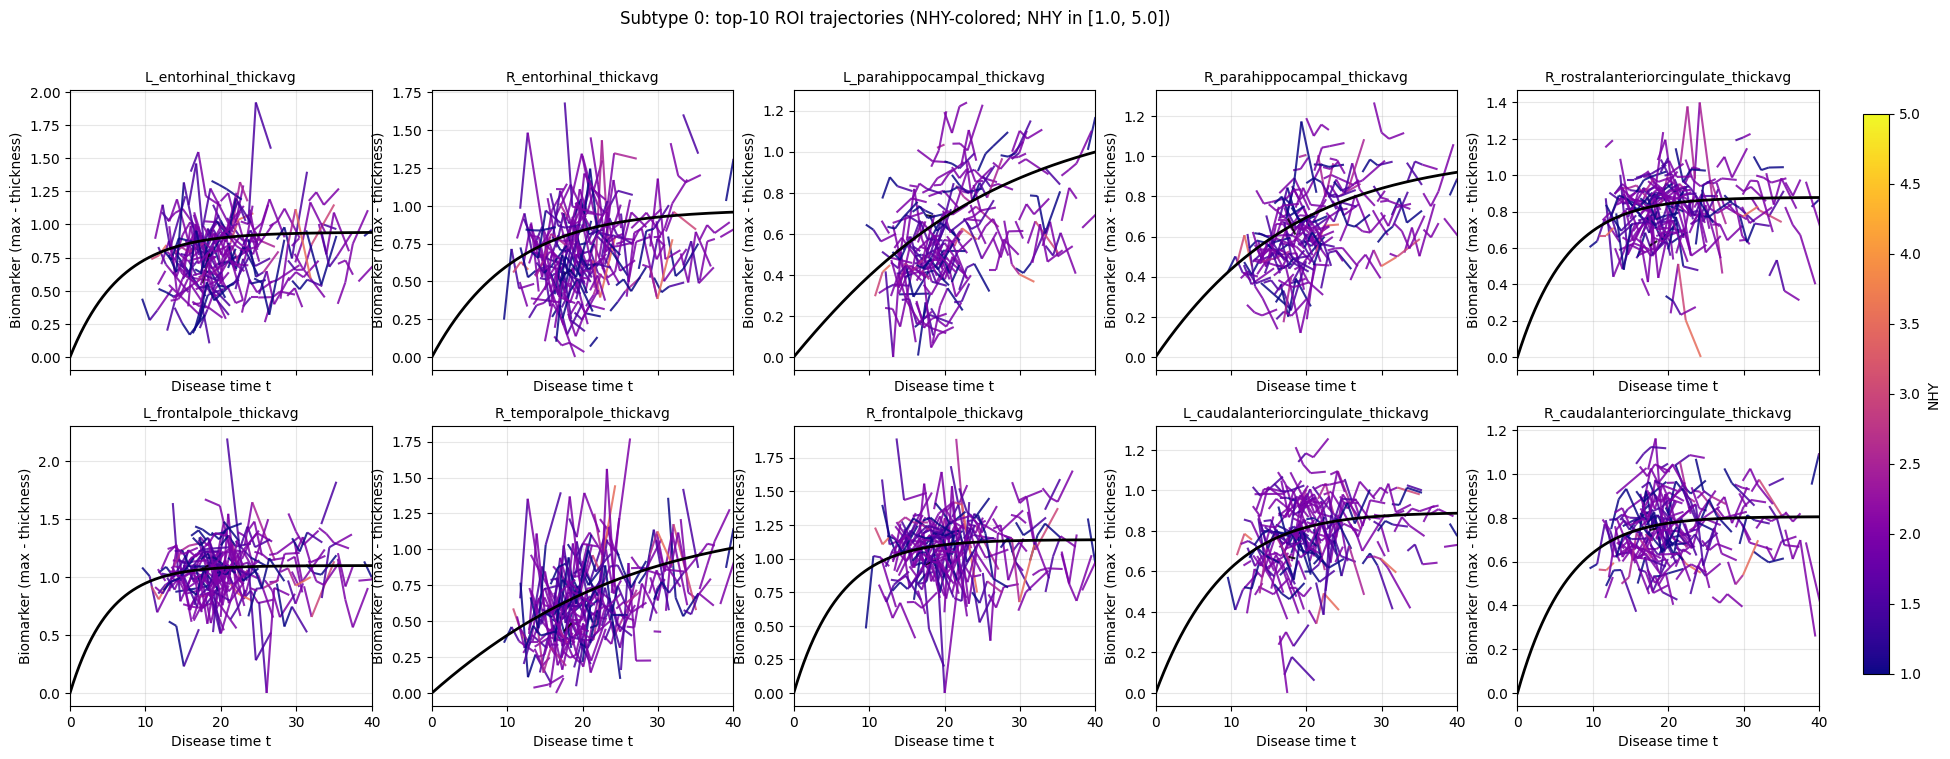

Subtype 1: 8 validation patients


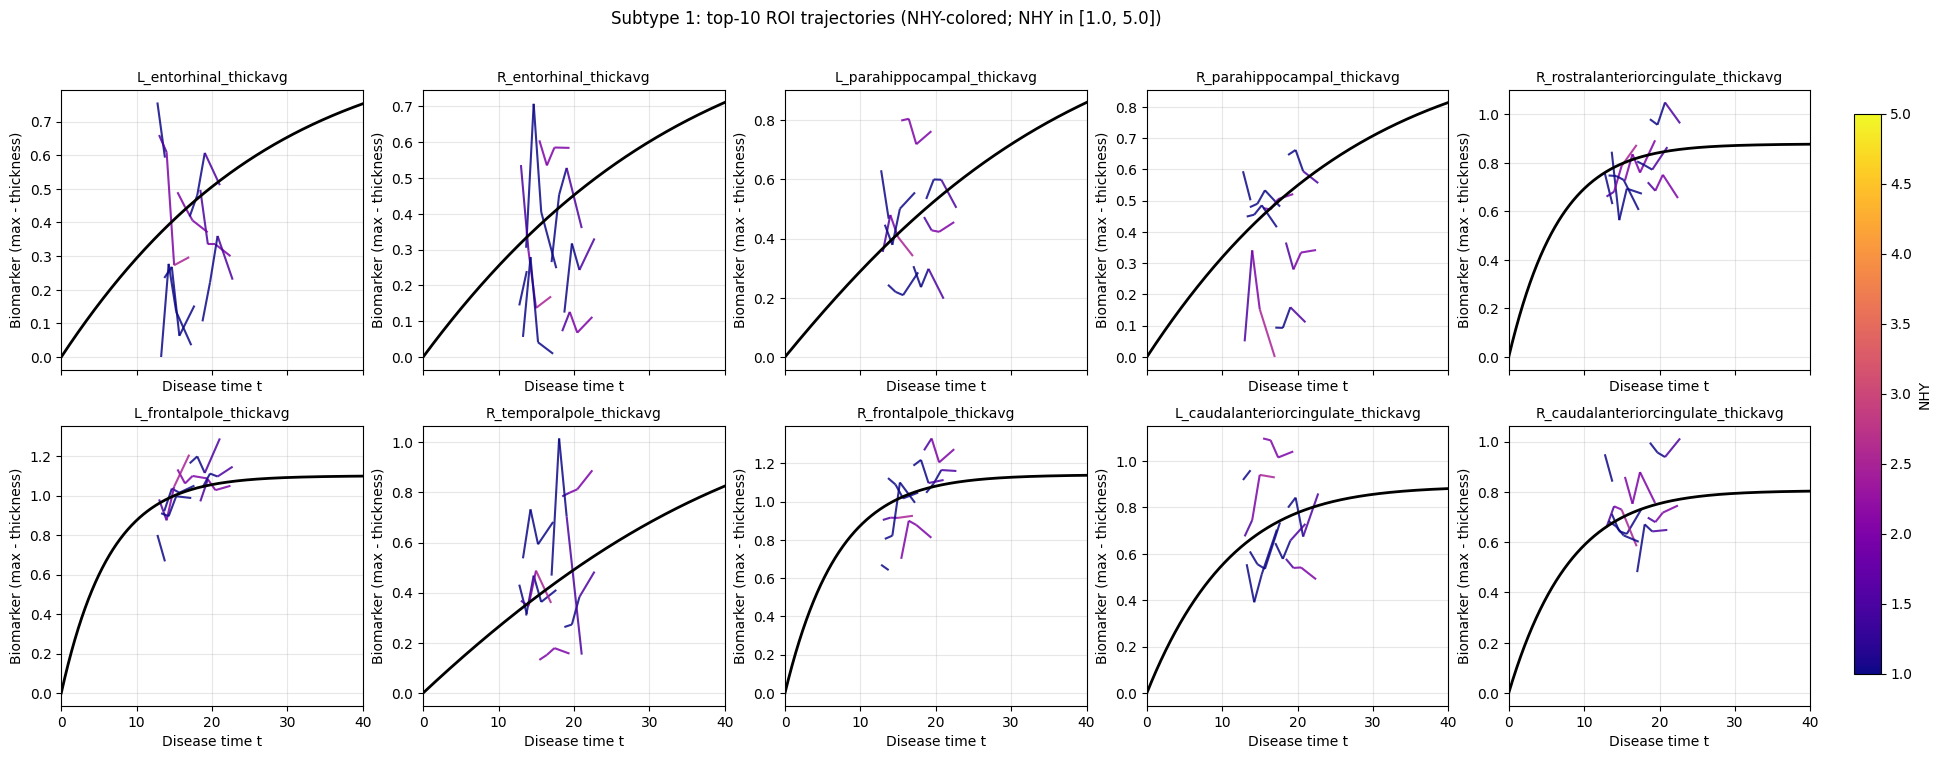

Subtype 2: 4 validation patients


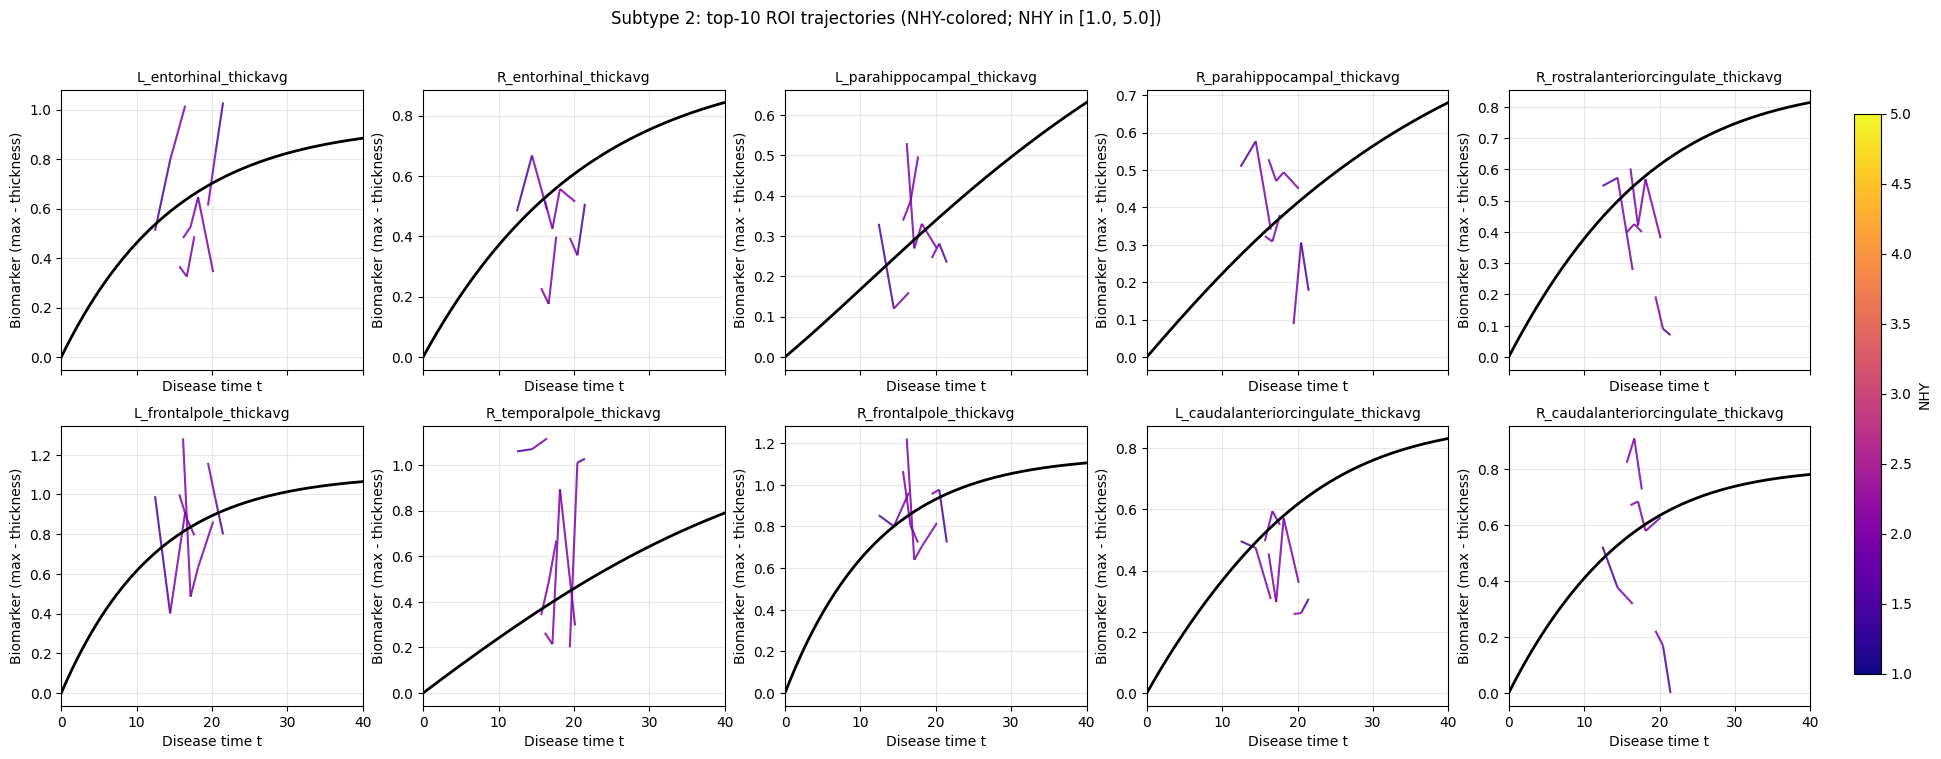

In [10]:
# 2x5 spaghetti on top-10 ROIs (by L2 metric), NHY-colored, one figure per subtype
from matplotlib.collections import LineCollection

NHY_VMIN, NHY_VMAX = 1.0, 5.0
norm_nhy = plt.Normalize(vmin=NHY_VMIN, vmax=NHY_VMAX)
cmap = plt.cm.plasma

for SUBTYPE in range(n_subtypes):
    pid_to_beta = {X_val[i]["id"]: float(beta_val[i]) for i in range(len(X_val))}
    pid_to_subtype = {X_val[i]["id"]: int(subtype_val[i]) for i in range(len(X_val))}

    idx_show = [i for i, p in enumerate(X_val) if pid_to_subtype.get(p["id"], -1) == SUBTYPE]
    print(f"Subtype {SUBTYPE}: {len(idx_show)} validation patients")

    fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharex=True)
    axes = axes.flatten()

    if len(idx_show) == 0:
        plt.suptitle(f"Subtype {SUBTYPE}: no validation patients")
        plt.show()
        continue

    for j, (ax, roi) in enumerate(zip(axes, top_indices)):
        for i in idx_show:
            p = X_val[i]
            t_ij = p["dt"] + pid_to_beta[p["id"]]
            y = p["X_obs"][:, roi]
            nhy = p["nhy"]

            order = np.argsort(t_ij)
            t_sorted = t_ij[order]
            y_sorted = y[order]
            nhy_sorted = nhy[order]

            if len(t_sorted) < 2:
                continue

            pts = np.column_stack([t_sorted, y_sorted])
            segments = np.stack([pts[:-1], pts[1:]], axis=1)
            nhy_mid = 0.5 * (nhy_sorted[:-1] + nhy_sorted[1:])
            colors = cmap(norm_nhy(nhy_mid))

            lc = LineCollection(segments, colors=colors, alpha=0.85, lw=1.5)
            ax.add_collection(lc)

        model_curve = final_s[roi] * Xtraj_by_subtype[SUBTYPE, roi, :]
        ax.plot(em.t_span, model_curve, "k-", lw=2)

        ax.set_title(top_ROI_names[j], fontsize=10)
        ax.set_xlabel("Disease time t")
        ax.set_ylabel("Biomarker (max - thickness)")
        ax.grid(True, alpha=0.3)
        ax.autoscale()
        ax.set_xlim(0, t_max)

    fig.subplots_adjust(right=0.92)
    cax = fig.add_axes([0.94, 0.15, 0.012, 0.7])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_nhy)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, label="NHY")

    plt.suptitle(
        f"Subtype {SUBTYPE}: top-10 ROI trajectories (NHY-colored; NHY in [{NHY_VMIN}, {NHY_VMAX}])"
    )
    plt.show()

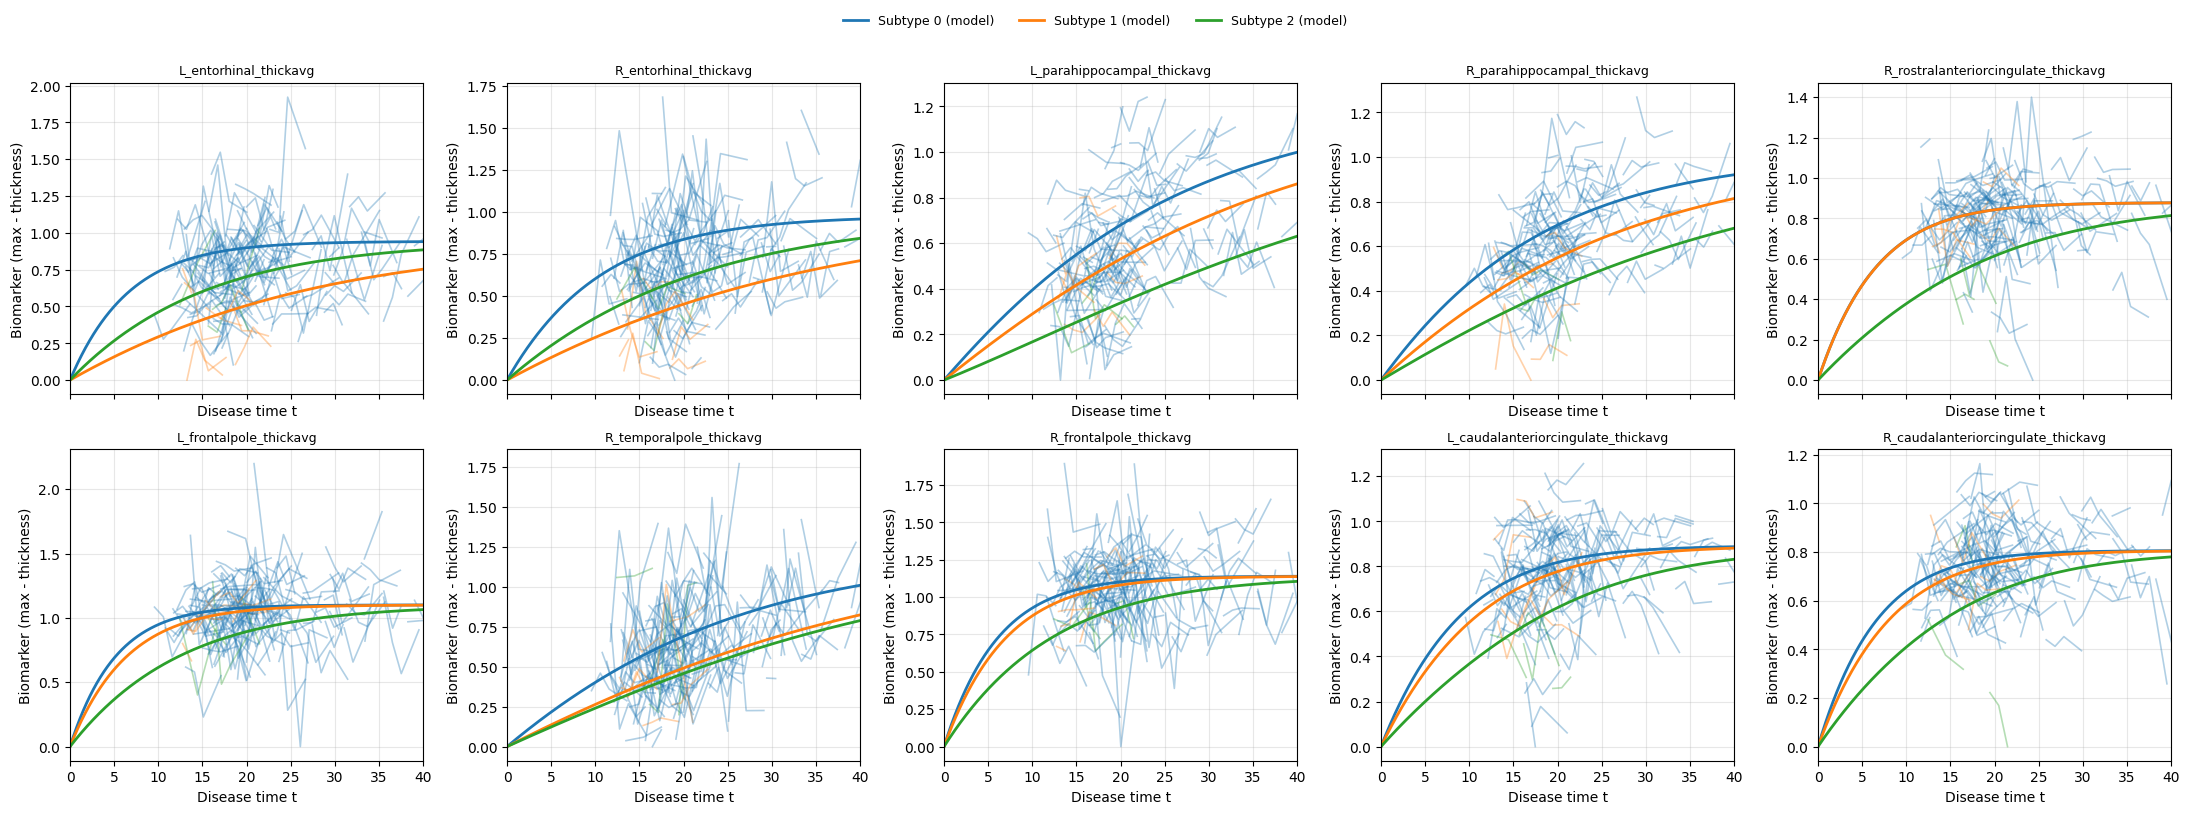

In [11]:
# Spaghetti: top-10 ROIs (2x5), patient lines colored by subtype + subtype model curves
import matplotlib.pyplot as plt
import numpy as np

pid_to_beta = {X_val[i]["id"]: float(beta_val[i]) for i in range(len(X_val))}
pid_to_assignment = {X_val[i]["id"]: int(subtype_val[i]) for i in range(len(X_val))}

subtype_colors = plt.cm.tab10(np.arange(n_subtypes) / 10.0)
patient_alpha = 0.35

x0 = np.zeros(n_biomarkers)
Xtraj_by_subtype = [
    solve_system(x0, cluster_f[k], K, em.t_span, final_scalar_K) for k in range(n_subtypes)
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharex=True)
axes = axes.flatten()

for j, (roi_idx, roi_name) in enumerate(zip(top_indices, top_ROI_names)):
    ax = axes[j]

    for p in X_val:
        pid = p["id"]
        sub = pid_to_assignment.get(pid, -1)
        if sub < 0:
            continue
        t_vals = p["dt"] + pid_to_beta[pid]
        y_vals = p["X_obs"][:, roi_idx]
        if len(t_vals) < 2:
            continue
        order = np.argsort(t_vals)
        ax.plot(
            t_vals[order], y_vals[order],
            color=subtype_colors[sub], alpha=patient_alpha, linewidth=1.2,
        )

    for k in range(n_subtypes):
        ax.plot(
            em.t_span,
            final_s[roi_idx] * Xtraj_by_subtype[k][roi_idx],
            color=subtype_colors[k],
            linewidth=2.0,
        )

    ax.set_title(roi_name, fontsize=9)
    ax.set_xlabel("Disease time t")
    ax.set_ylabel("Biomarker (max - thickness)")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)

handles = [
    plt.Line2D([0], [0], color=subtype_colors[k], lw=2.0, label=f"Subtype {k} (model)")
    for k in range(n_subtypes)
]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=n_subtypes, fontsize=9, frameon=False)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()